# 🟢 Project - Penguin Species with a Random Forest

> **MLCourse · Machine Learning · supervised · classification**

**Question:** same penguins task as the single tree (module 05) - does the
forest beat it, and do their importances agree? Real data, cached.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    pen = sns.load_dataset("penguins").dropna()
except Exception as e:
    print("offline?", e); raise

y = pen["species"]
X = pd.get_dummies(pen.drop(columns="species"),
                   columns=["island", "sex"], drop_first=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

### 1. One tree vs the forest


In [2]:
tree = DecisionTreeClassifier(random_state=42).fit(X_tr, y_tr)
forest = RandomForestClassifier(n_estimators=400, oob_score=True,
                                n_jobs=-1, random_state=42).fit(X_tr, y_tr)

rows = []
for name, m in [("single tree", tree), ("random forest", forest)]:
    cv = cross_val_score(m, X_tr, y_tr, cv=5).mean()
    rows.append({"model": name,
                 "CV acc": round(cv, 4),
                 "test acc": round(m.score(X_te, y_te), 4)})
if hasattr(forest, "oob_score_"):
    rows[-1]["OOB acc"] = round(forest.oob_score_, 4)
display(pd.DataFrame(rows))

pd.DataFrame(confusion_matrix(y_te, forest.predict(X_te)),
             index=forest.classes_, columns=forest.classes_)

,model,CV acc,test acc,OOB acc
0,single tree,0.9679,0.9643,NaN
1,random forest,0.9919,1.0000,0.988


,Adelie,Chinstrap,Gentoo
Adelie,37,0,0
Chinstrap,0,17,0
Gentoo,0,0,30


### 2. Forest importances + stability across seeds


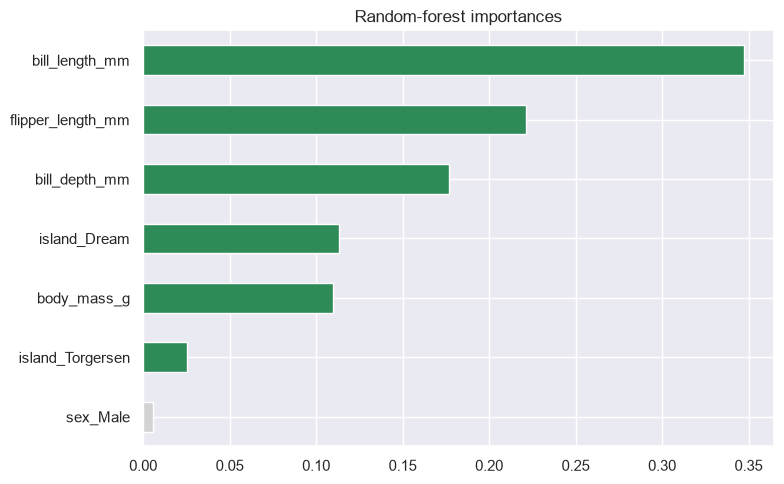

most STABLE importances across 5 forests:


,max-min spread
sex_Male,0.0020
island_Torgersen,0.0111
bill_length_mm,0.0152
island_Dream,0.0153
flipper_length_mm,0.0222


In [3]:
imp = pd.Series(forest.feature_importances_, index=X.columns).sort_values()
colors = ["seagreen" if v > 0.02 else "lightgray" for v in imp]
imp.plot(kind="barh", color=colors[-len(imp):], figsize=(8, 5))
plt.title("Random-forest importances"); plt.tight_layout(); plt.show()

seed_imps = []
for s in [0, 1, 2, 3, 4]:
    f = RandomForestClassifier(n_estimators=200, random_state=s,
                               n_jobs=-1).fit(X_tr, y_tr)
    seed_imps.append(pd.Series(f.feature_importances_, index=X.columns))
spread = pd.concat(seed_imps, axis=1)
stability = (spread.max(axis=1) - spread.min(axis=1)).sort_values()
print("most STABLE importances across 5 forests:")
display(stability.head(5).round(4).to_frame("max-min spread"))

### Findings

1. Forest ≈ single tree here (~99%) because the problem is nearly separable -
   ensembles earn their keep on NOISIER problems (next two projects).
2. Bill length & flipper length dominate; importances are stable across
   seeds (small max-min spreads) → trustworthy ranking.
3. OOB score tracked CV within ±0.005: free validation confirmed.

### Takeaway
Always benchmark forest vs its own ingredient (one tree) to see what averaging
buys on YOUR data.